In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.inspection import permutation_importance

## Load Dataset

In [2]:
df = pd.read_csv("CO2_Emissions.csv")

In [3]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## Basic feature analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [5]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


#### So no feature contains null values. We dont have to drop or impute any rows due to null values. YAAAAY

#### From the first look at the features we can observe that "Fuel Consumption Comb(L/100 Km)"(let's call this feature F1) represents how many literes of fuel is needed to cover 100Km, and "Fuel Consumption Comb(mpg)"(let's call this feature F2) represents how many miles can the vehicle travel with 1 gallon of fuel. 1 litre/100Km should approximately be 235.215 mpg. So feature F1 and F2 should capture the same property of the vehicle in different metrics. We should be able to approximately derive F1 from F2 and vice versa. F1 and F2 should be highly correlated. Let's cross check the same.

In [6]:
df[['Fuel Consumption Comb (L/100 km)',
    'Fuel Consumption Comb (mpg)']].corr()

,Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
Fuel Consumption Comb (L/100 km),1.000000,-0.925576
Fuel Consumption Comb (mpg),-0.925576,1.000000


#### Since the relation between F1 and F2 is inverse, the correlation coefficient will not be exactly -1. Correlation coefficient is meant to capture linear relationsh between variables the best. Let's derive the values from one feature in terms of the other feature and compare. 

In [7]:
derived_consumption_in_mpg = 235.215/df["Fuel Consumption Comb (L/100 km)"]
derived_consumption_in_mpg

0       27.672353
1       24.501563
2       39.866949
3       21.190541
4       22.190094
          ...    
7380    25.022872
7381    23.759091
7382    22.836408
7383    23.759091
7384    21.982710
Name: Fuel Consumption Comb (L/100 km), Length: 7385, dtype: float64

In [8]:
df['Fuel Consumption Comb (mpg)'].corr(derived_consumption_in_mpg)

np.float64(0.9992187631613796)

#### So the F1 and F2 are highly correlated and capture the same preoperty of the car in different units. Let's drop F2 and continue the analysis with F1

In [9]:
df.drop('Fuel Consumption Comb (mpg)', axis=1, inplace=True)

In [10]:
df

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,244
...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,232


#### "Fuel Consumption City (L/100 km)"(let's call it F3) and "Fuel Consumption Hwy (L/100 km)"(let's call it F4) features also look closely related to each other and to "Fuel Consumption Comb (L/100 km)"(also called F1) feature. Let's check

In [11]:
df[['Fuel Consumption Comb (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)']].corr()

,Fuel Consumption Comb (L/100 km),Fuel Consumption Hwy (L/100 km)
Fuel Consumption Comb (L/100 km),1.000000,0.977299
Fuel Consumption Hwy (L/100 km),0.977299,1.000000


In [12]:
df[['Fuel Consumption Comb (L/100 km)',
    'Fuel Consumption City (L/100 km)']].corr()

,Fuel Consumption Comb (L/100 km),Fuel Consumption City (L/100 km)
Fuel Consumption Comb (L/100 km),1.00000,0.99381
Fuel Consumption City (L/100 km),0.99381,1.00000


In [13]:
df[['Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption City (L/100 km)']].corr()

,Fuel Consumption Hwy (L/100 km),Fuel Consumption City (L/100 km)
Fuel Consumption Hwy (L/100 km),1.00000,0.94818
Fuel Consumption City (L/100 km),0.94818,1.00000


#### From the above correlations we can see that "Fuel Consumption Comb (L/100 km)" is highly correlated with 'Fuel Consumption Hwy (L/100 km)' and 'Fuel Consumption City (L/100 km)' feature, but the city fuel consumption and highway fuel consumption are slightly less corealted. 
#### Intuitively speaking, they should have a relation in the following format: ``F1 = a*F3 + (1-a)*F4, where 0<=a<=1``
#### Let's train a quick linear regression model to check if it's true:

In [14]:
X = df[['Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption City (L/100 km)']]
y = df['Fuel Consumption Comb (L/100 km)']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)

In [16]:
X_train.head()

,Fuel Consumption Hwy (L/100 km),Fuel Consumption City (L/100 km)
7335,4.5,4.4
2193,8.2,11.6
4019,8.3,10.2
7089,9.1,12.3
6448,13.8,18.4


In [17]:
y_train.head()

7335     4.5
2193    10.1
4019     9.2
7089    10.9
6448    16.4
Name: Fuel Consumption Comb (L/100 km), dtype: float64

In [18]:
reg = LinearRegression().fit(X_train, y_train)

In [19]:
reg.score(X_train, y_train)

0.9997986284672039

In [20]:
reg.coef_

array([0.44999583, 0.55006013])

In [21]:
reg.intercept_

np.float64(-0.0005359040096273304)

In [22]:
reg.score(X_test, y_test)

0.9997149013476112

Here we can clearly see that our intuition: ``F1 = a*F3 + (1-a)*F4, where 0<=a<=1`` holds true. The intercept value is very close to zero. and the coefficients for the the input features are between 0 and 1 and add upto 1. The R-squared value on training data as well as on testing data is also very close to 1 further solidying the fact that: ``F1 = a*F3 + (1-a)*F4, where 0<=a<=1``.

Let's drop 'Fuel Consumption Comb (L/100 km)' also.

In [23]:
df.drop('Fuel Consumption Comb (L/100 km)', axis=1, inplace=True)

In [24]:
df

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,244
...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,232


#### Now that the obvious feature issues have been resolved, let's continue with univariate feature analyis

#### 1. Make

In [25]:
make_counts = df['Make'].value_counts()
make_counts

Make
FORD             628
CHEVROLET        588
BMW              527
MERCEDES-BENZ    419
PORSCHE          376
TOYOTA           330
GMC              328
AUDI             286
NISSAN           259
JEEP             251
DODGE            246
KIA              231
HONDA            214
HYUNDAI          210
MINI             204
VOLKSWAGEN       197
MAZDA            180
LEXUS            178
JAGUAR           160
CADILLAC         158
SUBARU           140
VOLVO            124
INFINITI         108
BUICK            103
RAM               97
LINCOLN           96
MITSUBISHI        95
CHRYSLER          88
LAND ROVER        85
FIAT              73
ACURA             72
MASERATI          61
ROLLS-ROYCE       50
ASTON MARTIN      47
BENTLEY           46
LAMBORGHINI       41
ALFA ROMEO        30
GENESIS           25
SCION             22
SMART              7
BUGATTI            3
SRT                2
Name: count, dtype: int64

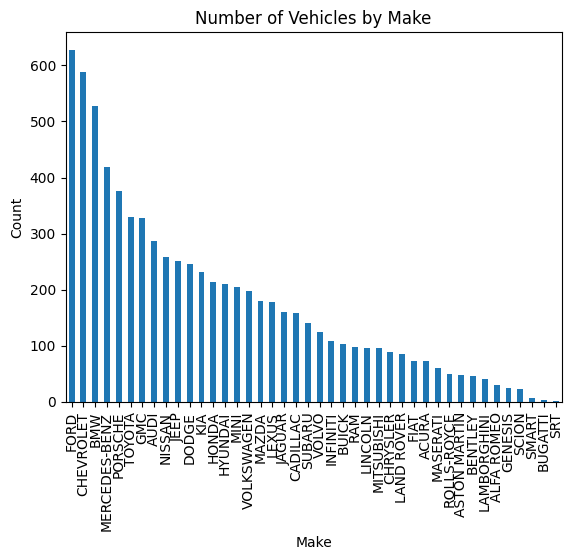

In [26]:
make_counts.plot(kind='bar')
plt.xlabel('Make')
plt.ylabel('Count')
plt.title('Number of Vehicles by Make')
plt.show()

In [27]:
make_counts[make_counts.values<=20]

Make
SMART      7
BUGATTI    3
SRT        2
Name: count, dtype: int64

In [28]:
make_counts.shape ## if we convert it to to numerical form using dummy encoding, this feature will take up 41 columns.

(42,)

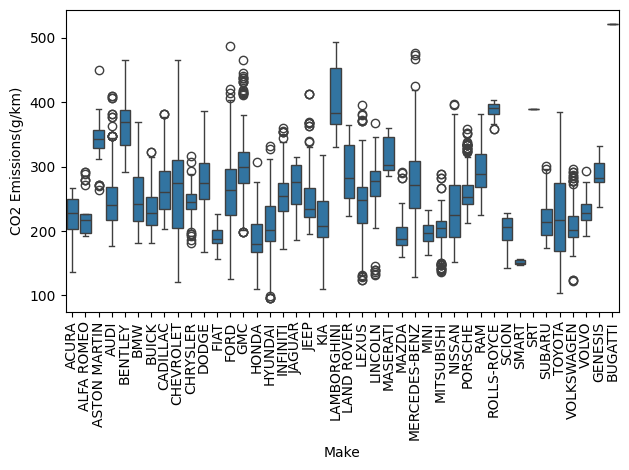

In [29]:
# visualize relationship between Make and CO2 emissions
sns.boxplot(
    data=df[['Make', 'CO2 Emissions(g/km)']],
    x='Make',
    y='CO2 Emissions(g/km)'
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 2. Models

In [30]:
model_counts = df['Model'].value_counts()
model_counts

Model
F-150 FFV 4X4           32
F-150 FFV               32
MUSTANG                 27
FOCUS FFV               24
SONIC                   20
                        ..
AVENTADOR S ROADSTER     1
HURACAN AWD              1
HURACAN SPYDER AWD       1
LS 500                   1
XC40 T4 AWD              1
Name: count, Length: 2053, dtype: int64

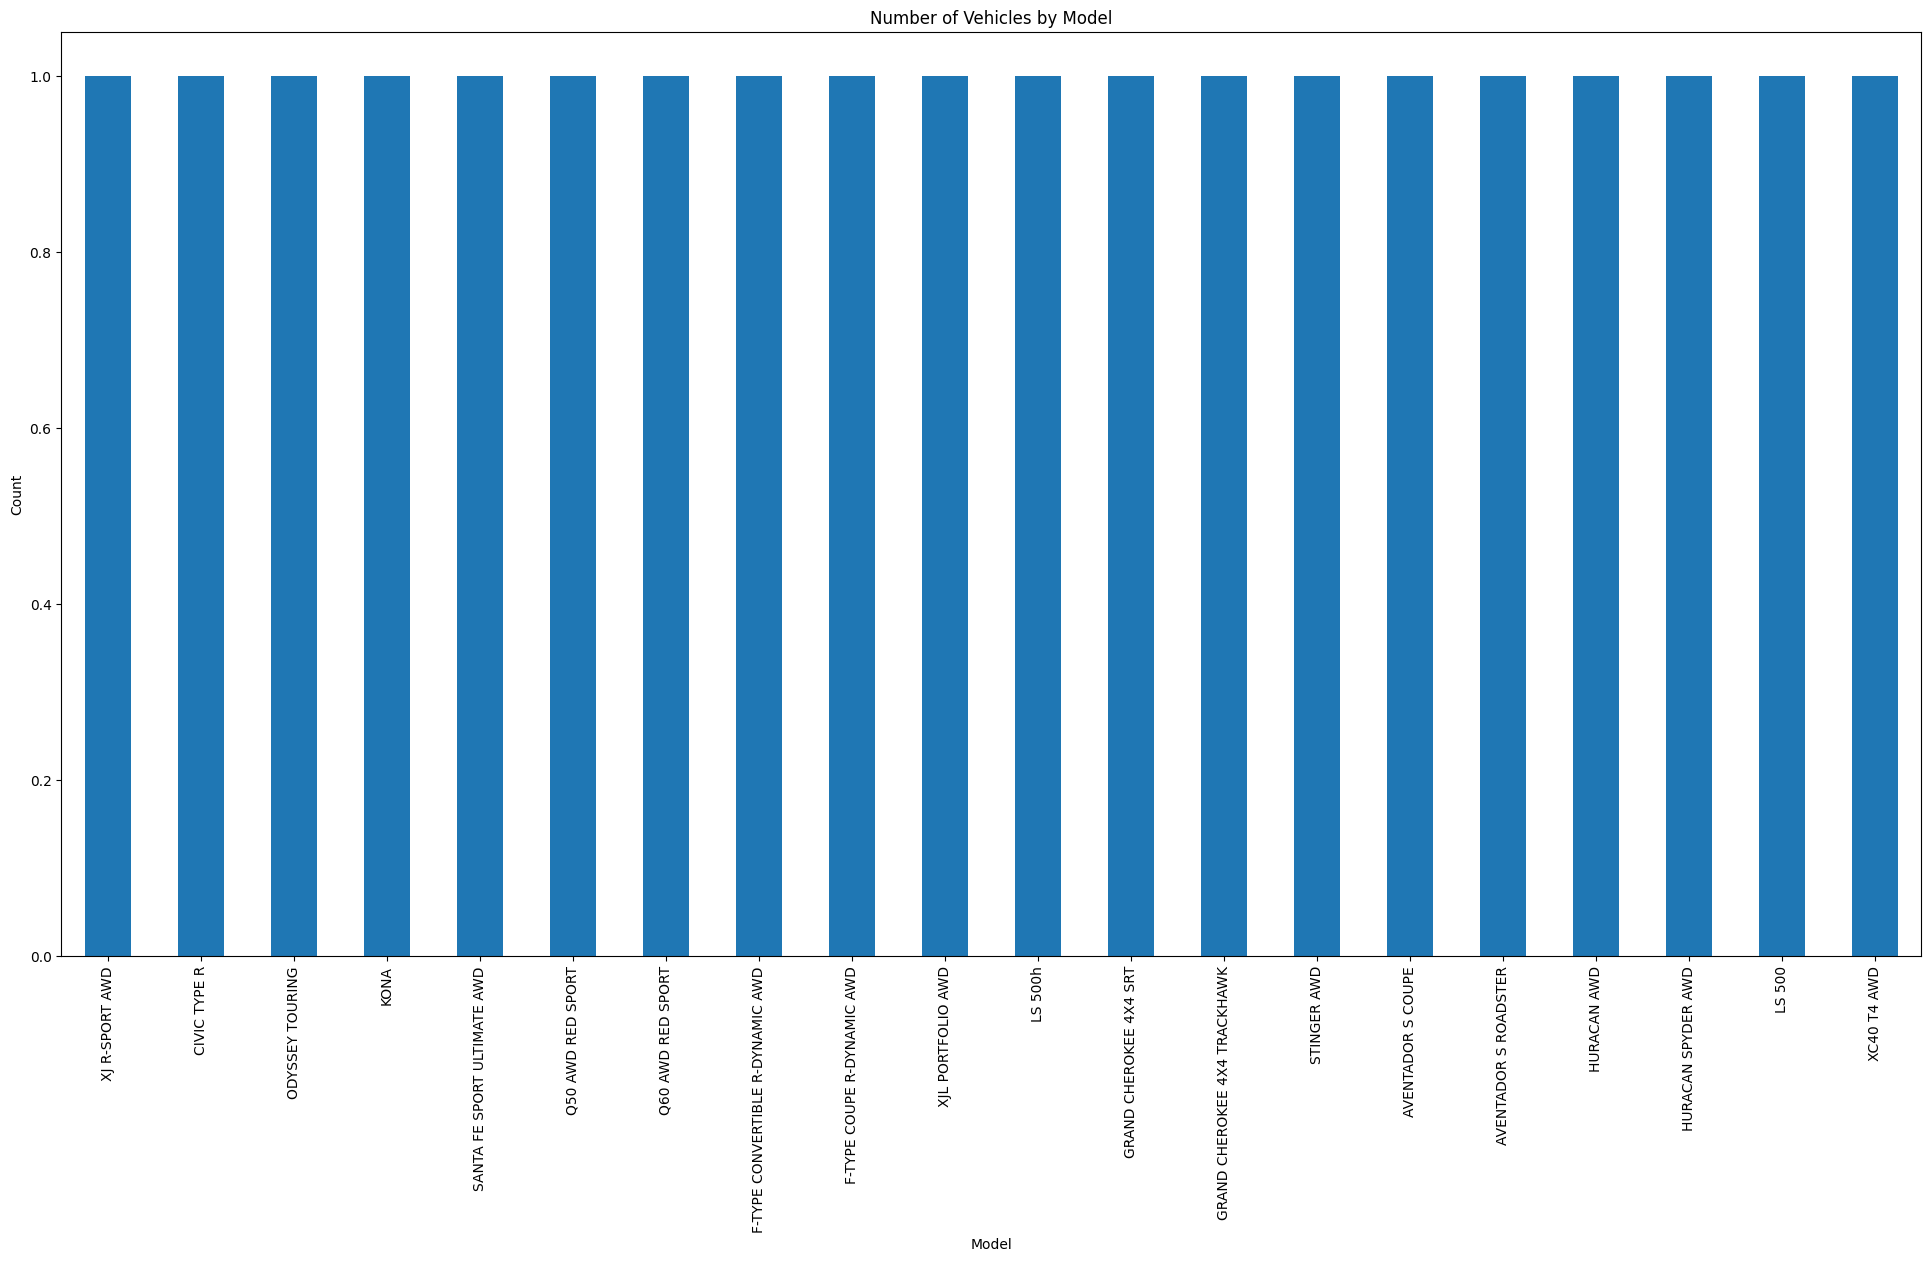

In [31]:
plt.figure(figsize=(24, 12))
model_counts.tail(20).plot(kind='bar')
plt.xlabel('Model')
plt.ylabel('Count')
plt.title('Number of Vehicles by Model')
plt.show()

In [32]:
model_counts[model_counts.values<=2]

# here there are 2053 models, more tha half of it occcurs one or two times. so number of data points for each model indivisually is very low 

Model
Cayenne S               2
Discovery               2
911 Targa 4 GTS         2
Discovery TD6 Diesel    2
Cayenne                 2
                       ..
AVENTADOR S ROADSTER    1
HURACAN AWD             1
HURACAN SPYDER AWD      1
LS 500                  1
XC40 T4 AWD             1
Name: count, Length: 1107, dtype: int64

In [33]:
model_counts[model_counts.values==3]

Model
John Cooper Works Countryman ALL4    3
911 Carrera 4S Cabriolet             3
CC 4MOTION                           3
GL 550 4MATIC                        3
TOUAREG TDI (modified)               3
                                    ..
AMG GLE 43 4MATIC                    3
RS 5                                 3
EQUUS                                3
RLX                                  3
HIGHLANDER HYBRID AWD LE             3
Name: count, Length: 188, dtype: int64

In [34]:
model_counts[model_counts.values>=10]

Model
F-150 FFV 4X4    32
F-150 FFV        32
MUSTANG          27
FOCUS FFV        24
SONIC            20
                 ..
CAYMAN           10
M6 GRAN COUPE    10
M6 CABRIOLET     10
BOXSTER S        10
ESCAPE AWD       10
Name: count, Length: 148, dtype: int64

#### 3. Vehicle Class

In [35]:
vehicle_class_counts = df['Vehicle Class'].value_counts()
vehicle_class_counts

Vehicle Class
SUV - SMALL                 1217
MID-SIZE                    1133
COMPACT                     1022
SUV - STANDARD               735
FULL-SIZE                    639
SUBCOMPACT                   606
PICKUP TRUCK - STANDARD      538
TWO-SEATER                   460
MINICOMPACT                  326
STATION WAGON - SMALL        252
PICKUP TRUCK - SMALL         159
MINIVAN                       80
SPECIAL PURPOSE VEHICLE       77
VAN - PASSENGER               66
STATION WAGON - MID-SIZE      53
VAN - CARGO                   22
Name: count, dtype: int64

In [36]:
vehicle_class_counts.shape 
# This seems like a useful feature. There are just 16 unique vehicle classes each of which has atleast 22 datapoints. 

(16,)

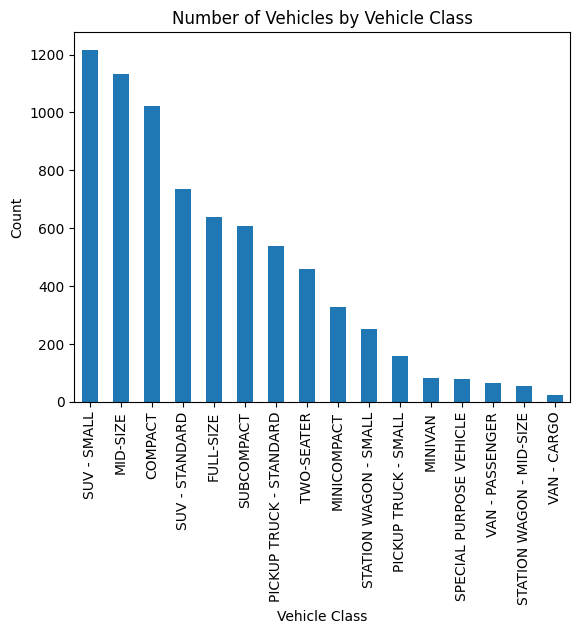

In [37]:
vehicle_class_counts.tail(200).plot(kind='bar')
plt.xlabel('Vehicle Class')
plt.ylabel('Count')
plt.title('Number of Vehicles by Vehicle Class')
plt.show()

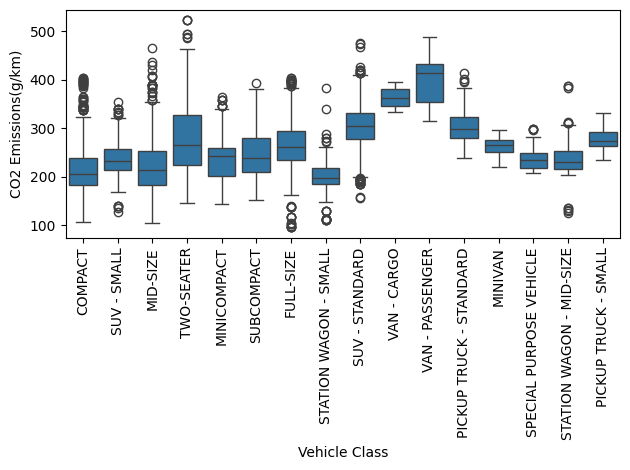

In [38]:
# visualize relationship between Vehicle Class and CO2 emissions
sns.boxplot(
    data=df[['Vehicle Class', 'CO2 Emissions(g/km)']],
    x='Vehicle Class',
    y='CO2 Emissions(g/km)'
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 4. Engine Size(L)

In [39]:
engine_size_counts = df['Engine Size(L)'].value_counts()
engine_size_counts

Engine Size(L)
2.0    1460
3.0     804
3.6     536
3.5     529
2.5     423
2.4     346
1.6     302
5.3     290
1.8     216
1.4     211
5.0     207
1.5     207
4.0     198
6.2     162
4.4     131
5.7     116
3.8     114
3.7     112
2.7      99
6.0      94
3.3      85
4.7      78
3.4      52
5.5      52
4.3      52
2.3      51
5.2      48
6.4      46
5.6      36
3.2      35
4.8      32
4.6      32
6.6      29
1.2      25
6.7      25
2.8      24
2.9      23
1.0      18
6.5      18
4.2      14
1.3      11
5.4       8
6.8       8
2.1       5
8.4       5
5.9       5
6.3       3
0.9       3
8.0       3
5.8       1
2.2       1
Name: count, dtype: int64

In [40]:
engine_size_counts.shape

(51,)

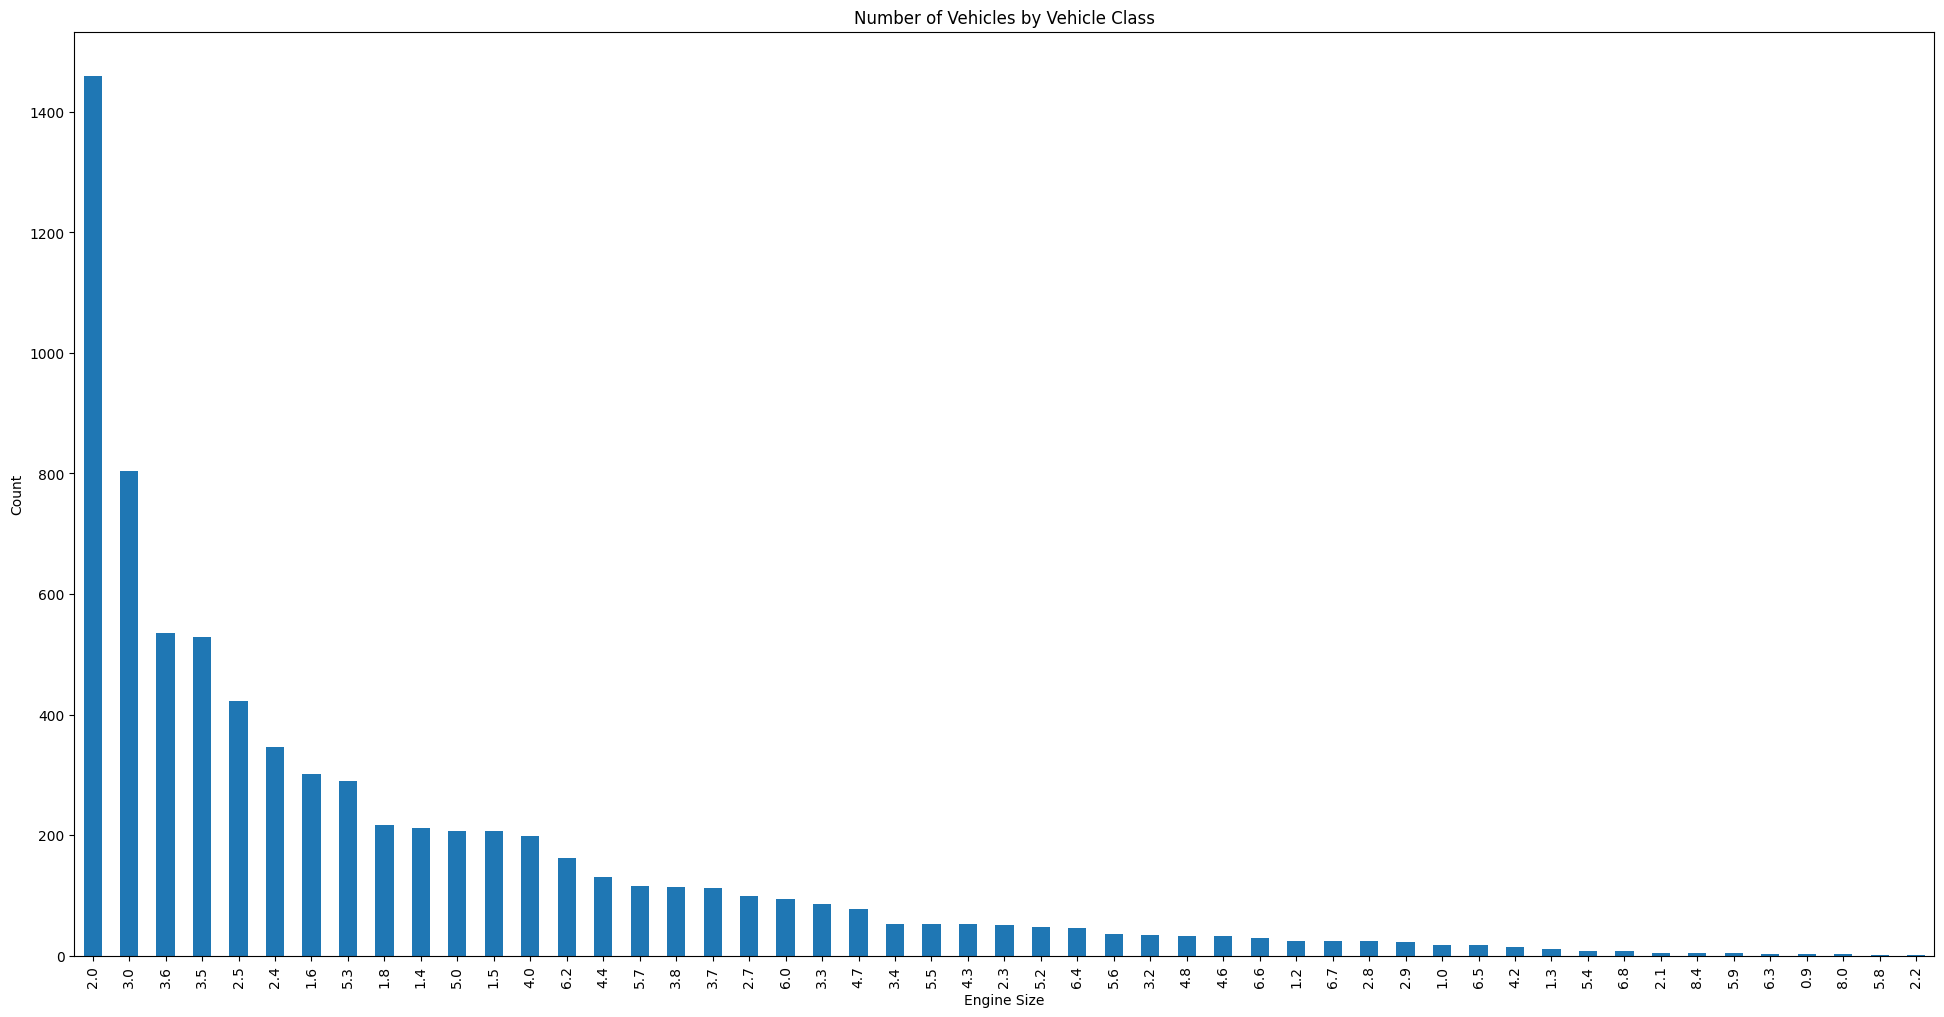

In [41]:
plt.figure(figsize=(24, 12))
engine_size_counts.plot(kind="bar")
plt.xlabel('Engine Size')
plt.ylabel('Count')
plt.title('Number of Vehicles by Vehicle Class')
plt.show()

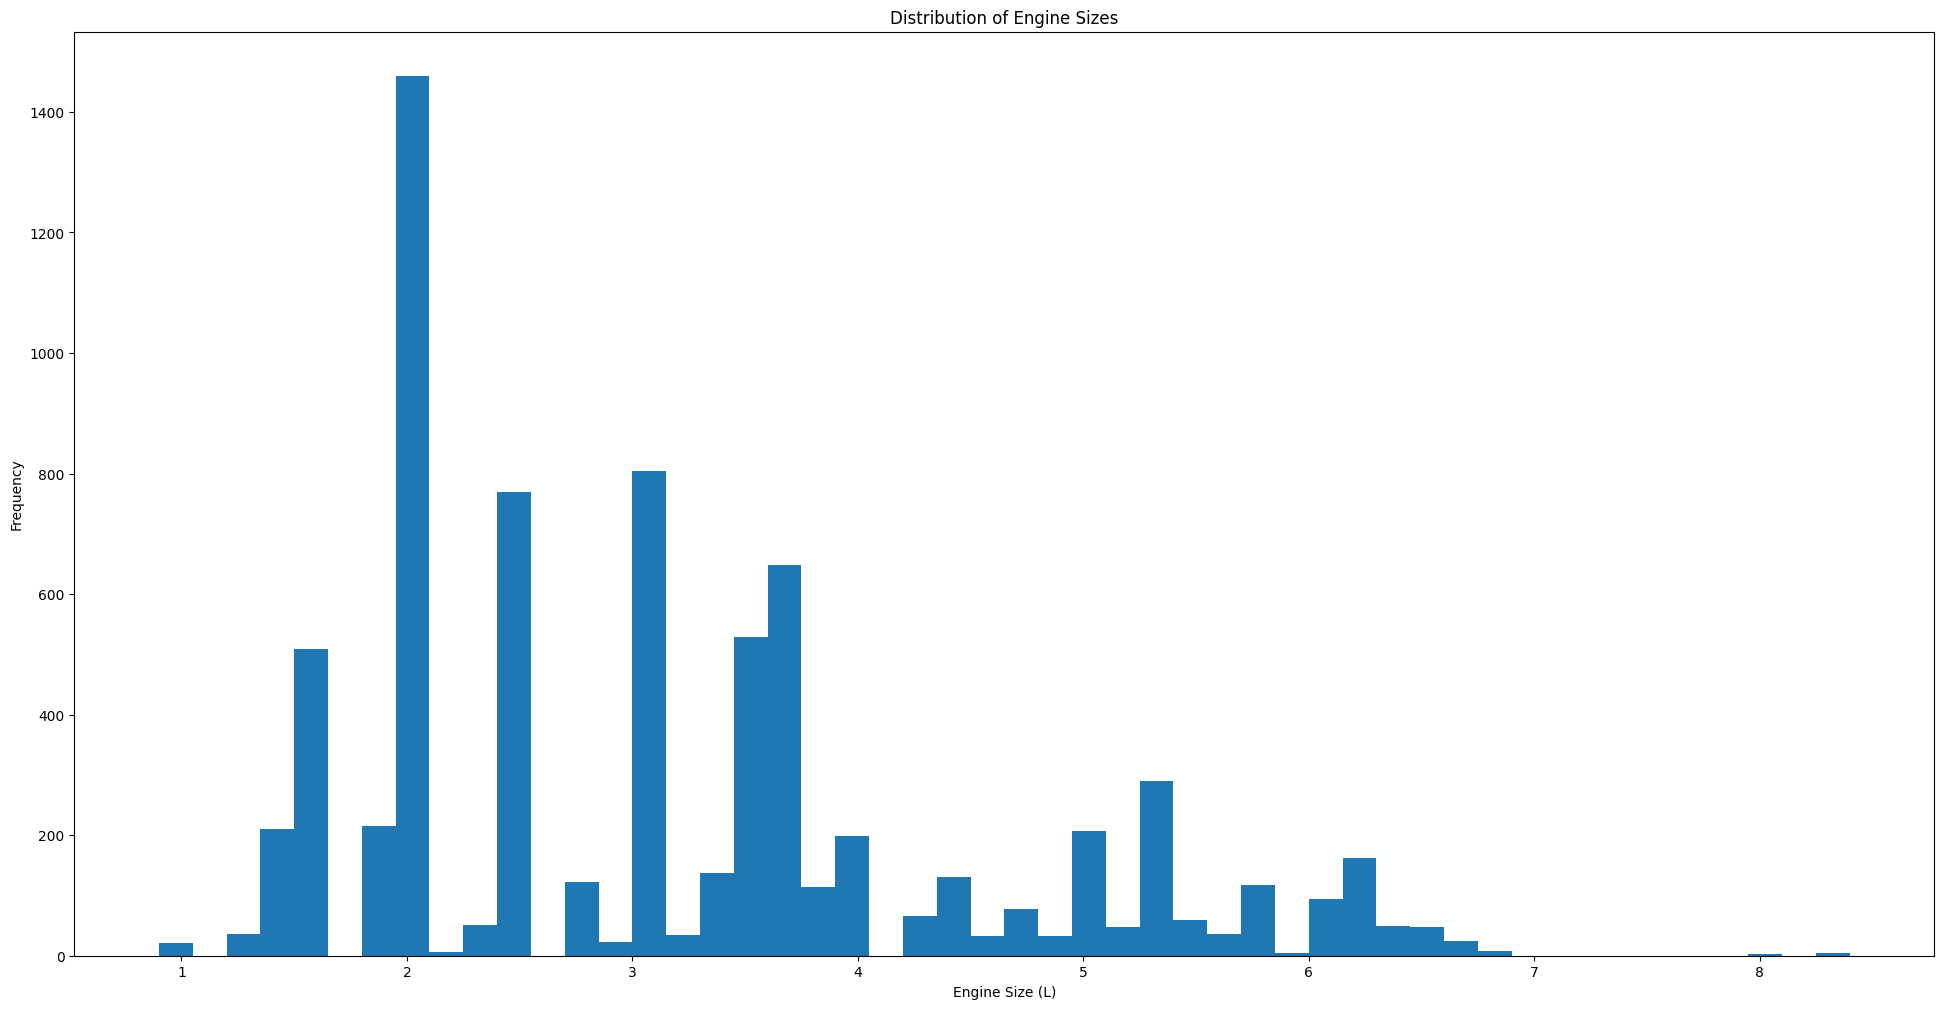

In [42]:
plt.figure(figsize=(24, 12))
plt.hist(df['Engine Size(L)'], bins=50)

plt.xlabel('Engine Size (L)')
plt.ylabel('Frequency')
plt.title('Distribution of Engine Sizes')
plt.show()

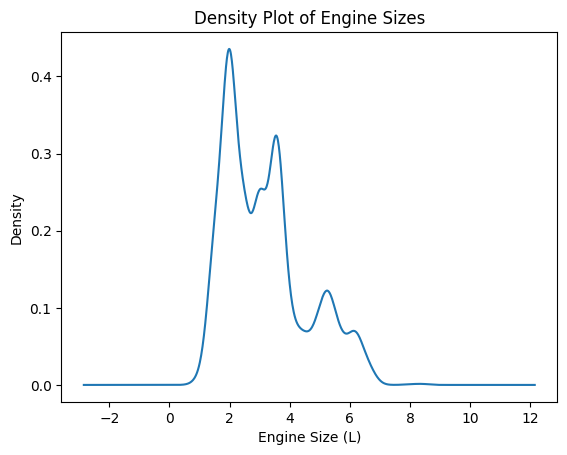

In [43]:
df['Engine Size(L)'].plot(kind='density')

plt.xlabel('Engine Size (L)')
plt.title('Density Plot of Engine Sizes')
plt.show()

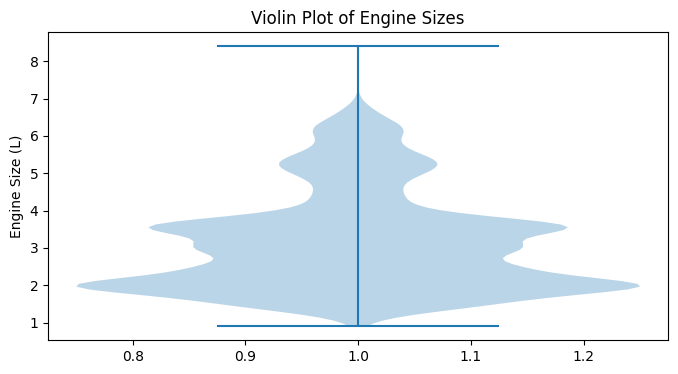

In [44]:
plt.figure(figsize=(8, 4))
plt.violinplot(df['Engine Size(L)'])

plt.ylabel('Engine Size (L)')
plt.title('Violin Plot of Engine Sizes')
plt.show()

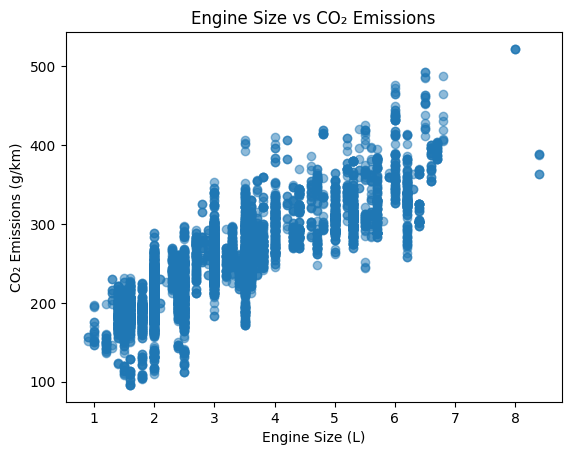

In [45]:
# visualize relationship between Engnie Size and CO2 emissions
plt.scatter(
    df['Engine Size(L)'],
    df['CO2 Emissions(g/km)'],
    alpha=0.5
)

plt.xlabel('Engine Size (L)')
plt.ylabel('CO₂ Emissions (g/km)')
plt.title('Engine Size vs CO₂ Emissions')

plt.show()

#### This feature looks like a numeric feature, but its actually a categorical feature.
#### Engine Size can take only a certain specific size The vertical line pattern in the scatter plot confirm the same thing. A general trend seems like more the engine size, more the CO2 emissions

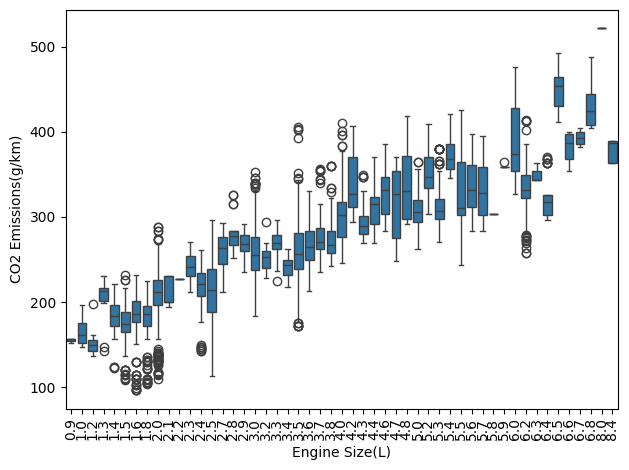

In [46]:
# visualize relationship between Engine Size(L) and CO2 emissions
sns.boxplot(
    data=df[['Engine Size(L)', 'CO2 Emissions(g/km)']],
    x='Engine Size(L)',
    y='CO2 Emissions(g/km)'
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 5. Cylinders

In [47]:
cylinders_counts = df['Cylinders'].value_counts()
cylinders_counts

Cylinders
4     3220
6     2446
8     1402
12     151
3       95
10      42
5       26
16       3
Name: count, dtype: int64

In [48]:
cylinders_counts.shape

(8,)

#### This feature looks like a numeric feature, but its actually a categorical feature. 
#### Cylinders can't take any random numeric value. Cylinders can't be 200 or -2 or 3.5. There is no theoretical limit to how many cylinders an engine can have, however the maximum is 16 cylinders(used in most expesnsive super cars) So the values will be greater than 1 and less than equal to 16. So this gives us a finite number of values / categories than the cylinder can have. 
#### However, converting it to catgorical feature and then back into numeric form doesn't make sense here. Suppose we convert it to categorical feature, then when we convert it back to numeric form, we'll have to use ordinal encoding to capture the ordering between different cylinder classes. The Cylinders feature is already in that format. We have cylinder values which are numeric that establish an ordering between different cylinder classes. So no need to take a few extra steps.

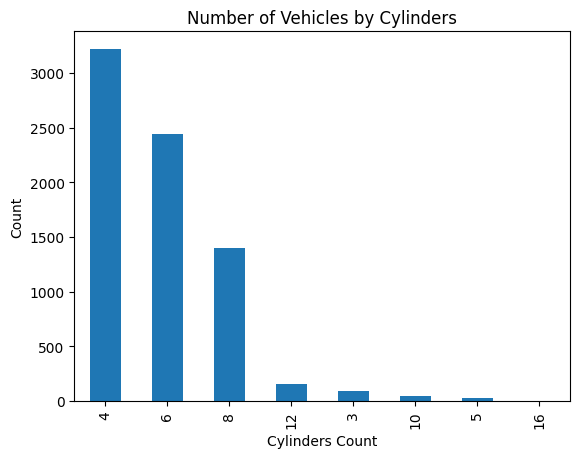

In [49]:
cylinders_counts.plot(kind="bar")
plt.xlabel('Cylinders Count')
plt.ylabel('Count')
plt.title('Number of Vehicles by Cylinders')
plt.show()

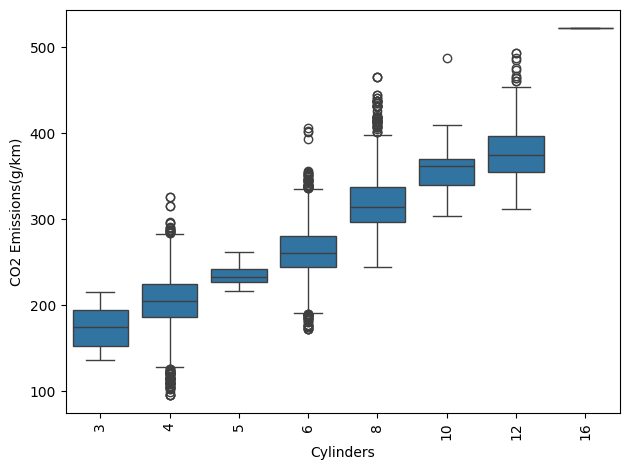

In [50]:
# visualize relationship between Cylinders Count and CO2 emissions
sns.boxplot(
    data=df[['Cylinders', 'CO2 Emissions(g/km)']],
    x='Cylinders',
    y='CO2 Emissions(g/km)'
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 6. Transmission	

In [51]:
transmission_counts = df['Transmission'].value_counts()
transmission_counts

Transmission
AS6     1324
AS8     1211
M6       901
A6       789
A8       490
AM7      445
A9       339
AS7      319
AV       295
M5       193
AS10     168
AM6      132
AV7      118
AV6      113
M7        91
A5        84
AS9       77
A4        65
AM8       62
A7        53
AV8       39
A10       31
AS5       26
AV10      11
AM5        4
AM9        3
AS4        2
Name: count, dtype: int64

In [52]:
transmission_counts.shape # should take up 26 columns when converted to dummy encoding

(27,)

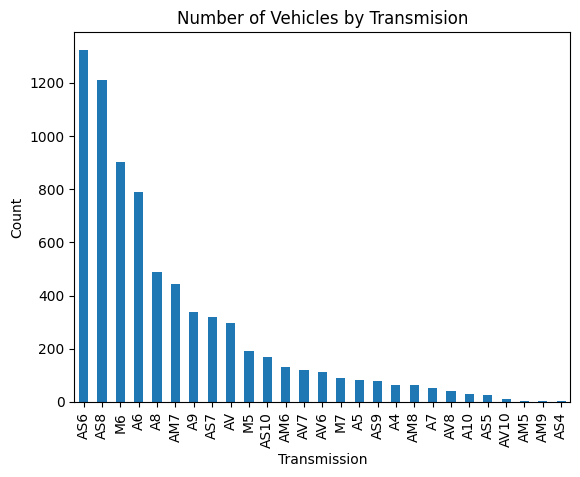

In [53]:
transmission_counts.plot(kind="bar")
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.title('Number of Vehicles by Transmision')
plt.show()

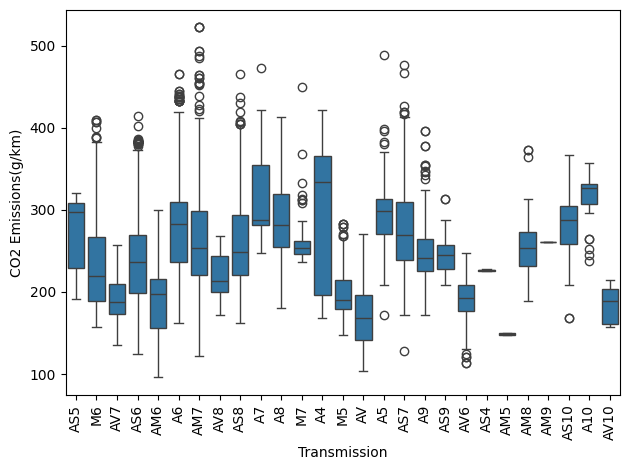

In [54]:
# visualize relationship between Transmission and CO2 emissions
sns.boxplot(
    data=df[['Transmission', 'CO2 Emissions(g/km)']],
    x='Transmission',
    y='CO2 Emissions(g/km)'
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 7. Fuel Type

In [55]:
fuel_type_counts = df['Fuel Type'].value_counts()
fuel_type_counts # Could be very important feature. Just 5 different categories with no inherent ordereing. Just take up 4 different columns in dummy encoding

Fuel Type
X    3637
Z    3202
E     370
D     175
N       1
Name: count, dtype: int64

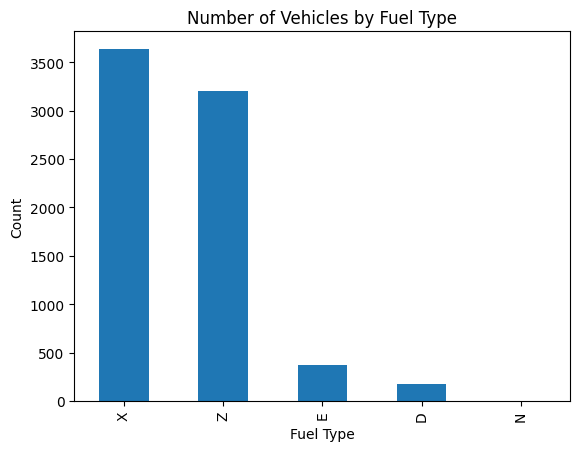

In [56]:
fuel_type_counts.plot(kind="bar")
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.title('Number of Vehicles by Fuel Type')
plt.show()

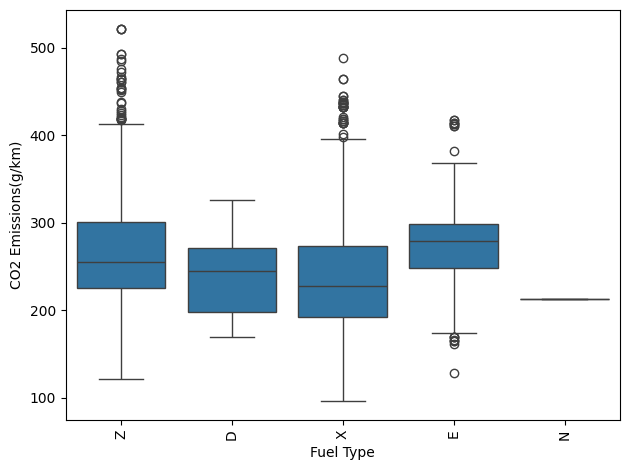

In [57]:
# visualize relationship between Fuel Type and CO2 emissions
sns.boxplot(
    data=df[['Fuel Type', 'CO2 Emissions(g/km)']],
    x='Fuel Type',
    y='CO2 Emissions(g/km)'
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 8. Fuel Consumption City (L/100 km)

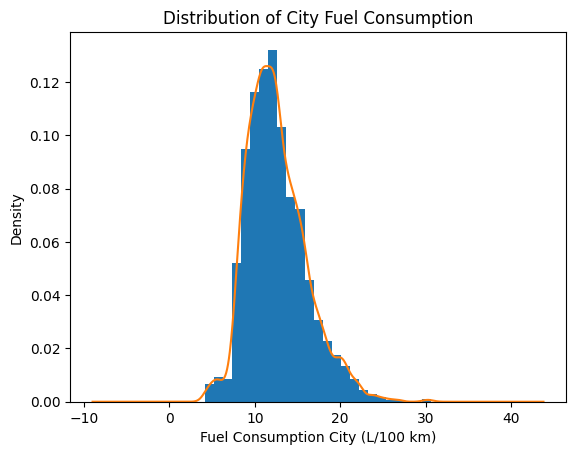

In [58]:
# Histogram
df['Fuel Consumption City (L/100 km)'].hist(
    bins=25,
    density=True
)

# Density line
df['Fuel Consumption City (L/100 km)'].plot(
    kind='density'
)

plt.xlabel('Fuel Consumption City (L/100 km)')
plt.ylabel('Density')
plt.title('Distribution of City Fuel Consumption')
plt.show()

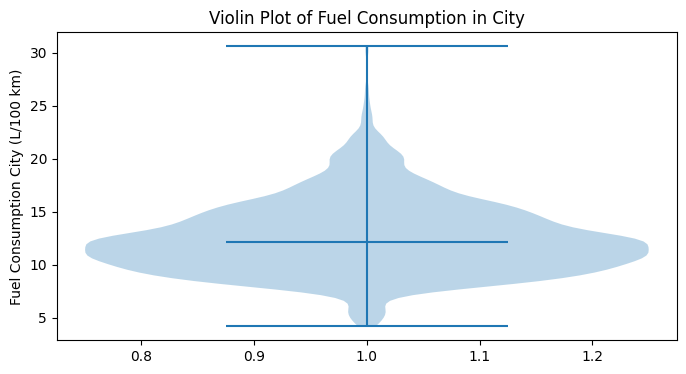

In [59]:
plt.figure(figsize=(8, 4))
plt.violinplot(df['Fuel Consumption City (L/100 km)'],
    showmedians=True,
    showextrema=True
)

plt.ylabel('Fuel Consumption City (L/100 km)')
plt.title('Violin Plot of Fuel Consumption in City')
plt.show()

#### 9. Fuel Consumption Hwy (L/100 km)

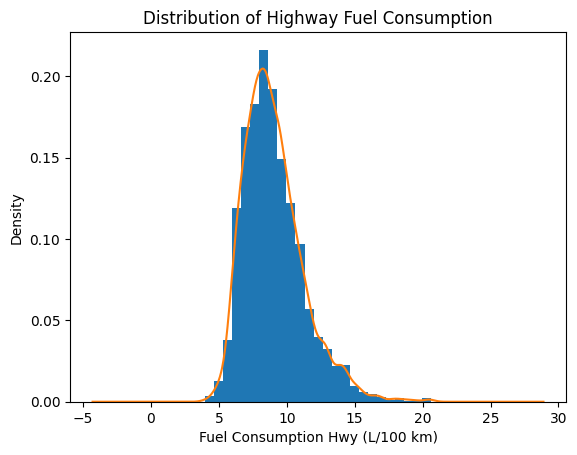

In [60]:
# Histogram
df['Fuel Consumption Hwy (L/100 km)'].hist(
    bins=25,
    density=True
)

# Density line
df['Fuel Consumption Hwy (L/100 km)'].plot(
    kind='density'
)

plt.xlabel('Fuel Consumption Hwy (L/100 km)')
plt.ylabel('Density')
plt.title('Distribution of Highway Fuel Consumption')
plt.show()

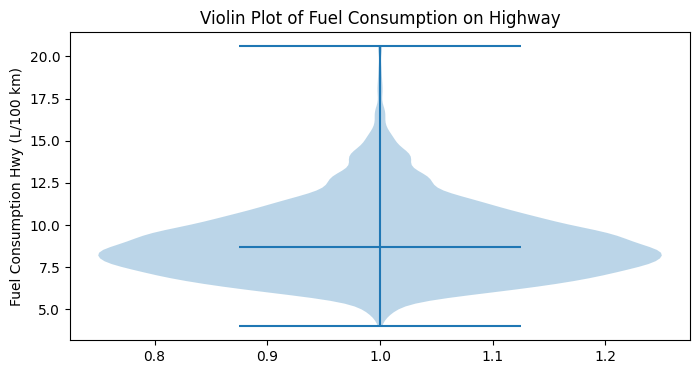

In [61]:
plt.figure(figsize=(8, 4))
plt.violinplot(df['Fuel Consumption Hwy (L/100 km)'],
    showmedians=True,
    showextrema=True
)

plt.ylabel('Fuel Consumption Hwy (L/100 km)')
plt.title('Violin Plot of Fuel Consumption on Highway')
plt.show()

#### Now let's try to analyse relation between 2 features at a time

#### Correlation matrix

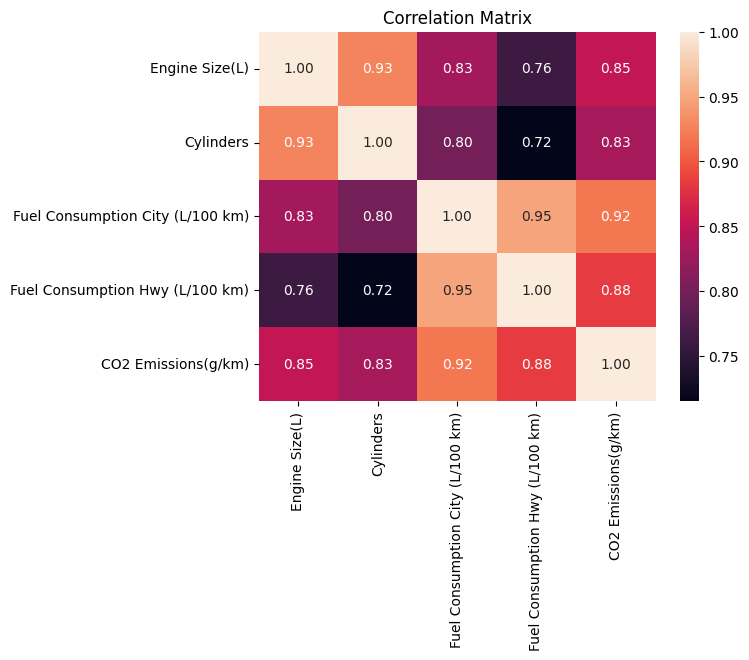

In [62]:
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,      # show correlation values
    fmt='.2f',       # 2 decimal places
)

plt.title('Correlation Matrix')
plt.show()

#### The lowest correlation value is 0.72, hence all numeric feature pairs are strongly correlated(amongst themselves and with the output feature).

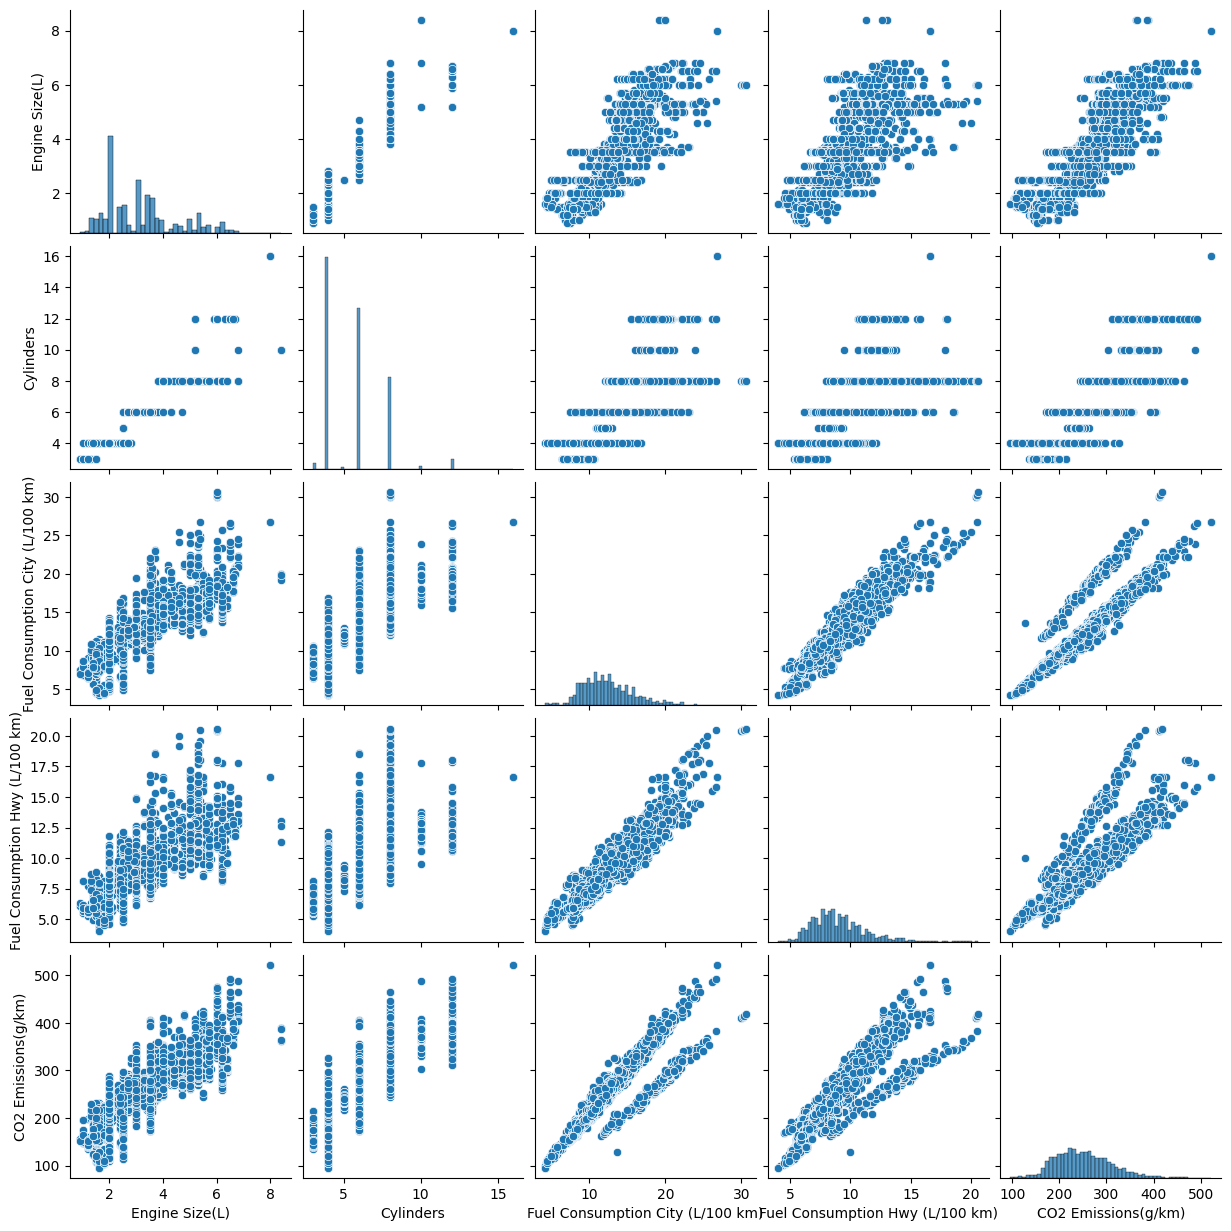

In [63]:
sns.pairplot(df)

plt.show()

#### Bivariate ananlysis between model and make

In [64]:
count_of_makes_for_each_model = df.groupby('Model')['Make'].nunique()
count_of_makes_for_each_model

Model
124 SPIDER    1
124 Spider    1
1500          1
1500 (MDS)    1
1500 4X4      1
             ..
iM            1
iQ            1
tC            1
xB            1
xD            1
Name: Make, Length: 2053, dtype: int64

In [65]:
count_of_makes_for_each_model.max()

np.int64(1)

#### So each model is associated with exactly one make.

#### There are 42 unique values of make and 2053 unique values for model. Most of the model occur once or twice in the dataset. Only 148 models have a frequency great than or equal to 10. If we continue with model, we'll have to add 2052 feature after dummy encoding. 

#### We have already seen that each model has one unique make, Model implies make. Model is the more detailed feature whereas Make is the more general feature. But Model adds a lot of sparse feature that may lead to overfitting of the model.

#### Let's get rid of Model

In [66]:
df.drop('Model', axis=1, inplace=True)

In [67]:
df

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),CO2 Emissions(g/km)
0,ACURA,COMPACT,2.0,4,AS5,Z,9.9,6.7,196
1,ACURA,COMPACT,2.4,4,M6,Z,11.2,7.7,221
2,ACURA,COMPACT,1.5,4,AV7,Z,6.0,5.8,136
3,ACURA,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,255
4,ACURA,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,244
...,...,...,...,...,...,...,...,...,...
7380,VOLVO,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,219
7381,VOLVO,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,232
7382,VOLVO,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,240
7383,VOLVO,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,232


### Train test split

In [68]:
X = df.drop('CO2 Emissions(g/km)', axis=1)
y = df['CO2 Emissions(g/km)']

In [69]:
X.head()

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km)
0,ACURA,COMPACT,2.0,4,AS5,Z,9.9,6.7
1,ACURA,COMPACT,2.4,4,M6,Z,11.2,7.7
2,ACURA,COMPACT,1.5,4,AV7,Z,6.0,5.8
3,ACURA,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1
4,ACURA,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7


In [70]:
y.head()

0    196
1    221
2    136
3    255
4    244
Name: CO2 Emissions(g/km), dtype: int64

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

### Scaling and Encoding

In [72]:
preprocessor = ColumnTransformer([
    ('scaled', StandardScaler(),  X_train.columns[(X_train.dtypes == 'int64') | (X_train.dtypes == 'float64')]),
    ('encoded', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), X_train.columns[X_train.dtypes == 'object']),
])

In [73]:
preprocessor # untrained

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaled', ...), ('encoded', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

### Setting up a pipeline to apply preprocessing and training model

In [74]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [75]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaled', ...), ('encoded', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [76]:
r2_train = model_pipeline.score(X_train, y_train)
r2_train

0.9923963964739831

In [77]:
r2_test = model_pipeline.score(X_test, y_test)
r2_test

0.9942696545134415

In [78]:
feature_names = model_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

regressor = model_pipeline.named_steps[
    'regressor'
]

In [79]:
feature_names[:5]

array(['scaled__Engine Size(L)', 'scaled__Cylinders',
       'scaled__Fuel Consumption City (L/100 km)',
       'scaled__Fuel Consumption Hwy (L/100 km)',
       'encoded__Make_ALFA ROMEO'], dtype=object)

In [80]:
coefficients = regressor.coef_
coefficients

array([ 2.27064738e-01,  1.14377497e+00,  4.27963337e+01,  2.20355092e+01,
        2.91321312e+00,  4.10944836e+00,  1.62245033e+00,  4.30831753e+00,
        1.40417884e+00,  1.19107401e+01,  3.04240344e+00,  2.38725890e+00,
        3.44150028e+00,  7.99491534e+00,  5.79077485e+00,  2.76564830e+00,
        5.71124088e+00,  5.66520753e+00,  3.26275139e+00,  2.59208578e+00,
        3.34315725e+00,  3.11086123e+00,  1.74229515e+00,  4.76822719e+00,
        3.72602634e+00,  3.83053120e+00, -7.81406200e-01,  9.75991694e-01,
        4.58038645e+00,  4.84482057e+00,  2.04755140e+00,  1.99048321e+00,
        1.27137837e+00,  2.22481043e+00,  4.42509175e+00,  1.97957411e+00,
        4.48707800e+00,  3.15860241e+00,  1.35848803e+00, -2.67015743e+00,
        2.66034761e+00,  3.41023431e+00,  2.47930962e+00,  1.91970328e+00,
        1.41951936e+00,  5.87030331e-01, -4.86910050e-01, -6.90970801e-01,
        6.01914180e-01,  4.83078264e+00,  1.74849977e+00,  3.10153239e+00,
        2.95821128e-01, -

In [81]:
intercept = regressor.intercept_
intercept

np.float64(283.1981565500296)

In [82]:
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'coefficient_magnitude': abs(coefficients),
})

coef_df.sort_values('coefficient_magnitude', ascending=False).T

,86,87,2,88,89,3,9,58,59,13,...,45,46,65,52,63,77,0,54,57,53
feature,encoded__Fuel Type_E,encoded__Fuel Type_N,scaled__Fuel Consumption City (L/100 km),encoded__Fuel Type_X,encoded__Fuel Type_Z,scaled__Fuel Consumption Hwy (L/100 km),encoded__Make_BUGATTI,encoded__Vehicle Class_VAN - CARGO,encoded__Vehicle Class_VAN - PASSENGER,encoded__Make_CHRYSLER,...,encoded__Vehicle Class_FULL-SIZE,encoded__Vehicle Class_MID-SIZE,encoded__Transmission_A9,encoded__Vehicle Class_STATION WAGON - MID-SIZE,encoded__Transmission_A7,encoded__Transmission_AS9,scaled__Engine Size(L),encoded__Vehicle Class_SUBCOMPACT,encoded__Vehicle Class_TWO-SEATER,encoded__Vehicle Class_STATION WAGON - SMALL
coefficient,-141.609865,-108.520741,42.796334,-29.961088,-28.514988,22.035509,11.91074,-10.590184,-10.229372,7.994915,...,0.58703,-0.48691,-0.34194,0.295821,0.294399,0.24,0.227065,-0.226074,0.203808,-0.084611
coefficient_magnitude,141.609865,108.520741,42.796334,29.961088,28.514988,22.035509,11.91074,10.590184,10.229372,7.994915,...,0.58703,0.48691,0.34194,0.295821,0.294399,0.24,0.227065,0.226074,0.203808,0.084611


#### r-squared for train and test is above 0.99, hence the linear regression model fits the data beautifully

### Assumptions of Linear Regression

#### 1. Linarity between input and output variable

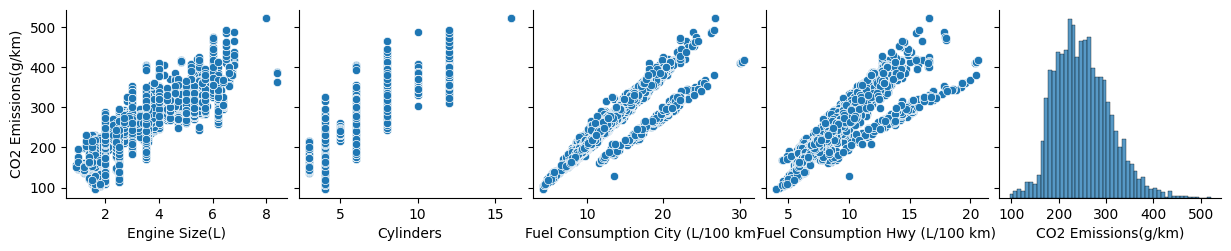

In [83]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

sns.pairplot(df, x_vars=numeric_cols, y_vars='CO2 Emissions(g/km)')

#### (Ignore Cylinders and CO2 Emissions plot in the above figure)

#### By looking at the plots we can see that with the CO2 emission variable the independent variables form an approximately linear shape. However for Fuel Consumption City and Highway, we can see that  there are 2 different cluster of points, though the overall trend can be modelled by linear regression, it is not prefectly linear and may lead to some problem. So it shows that a linear regression fitting may or may not be the best model for it. We'll have to check other assumptions closely as well.

#### 2. Residuals should be noramlly distributed

In [84]:
y_pred = model_pipeline.predict(X_test)

In [85]:
residuals = y_test - y_pred # actual - predicted value

In [86]:
residuals

1680    -4.107004
1522    -5.023839
1524    -5.855433
641      0.529926
326     -3.680699
          ...    
6556     0.760435
2417    -0.920908
1343   -11.174197
5238     1.084854
6829     2.413506
Name: CO2 Emissions(g/km), Length: 1477, dtype: float64

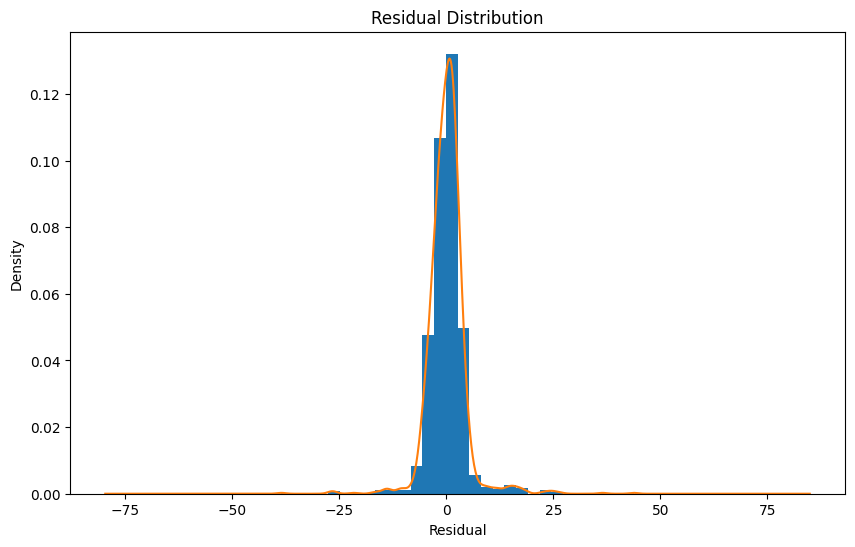

In [87]:
plt.figure(figsize=(10, 6))

# Histogram
plt.hist(residuals, bins=30, density=True)

# Density line
residuals.plot(kind='density')

plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Density')

plt.show()

#### The residuals look normally distributed around 0.

#### 3. Residuals vs Predicted values (Homoscedasticity)

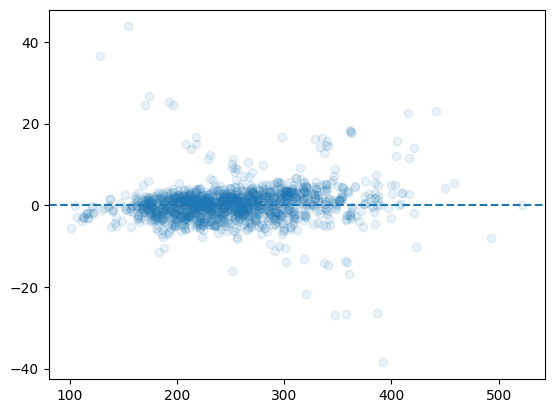

In [88]:
plt.scatter(y_pred, residuals, alpha = 0.1)
plt.axhline(y=0, linestyle='--')

#### The variance of residuals remains almost constant across all levels of the independent variables. Most of the residual values are closer to 0 and distibuted on both side of y = 0 axis.

#### 4. Independence of errors / residuals

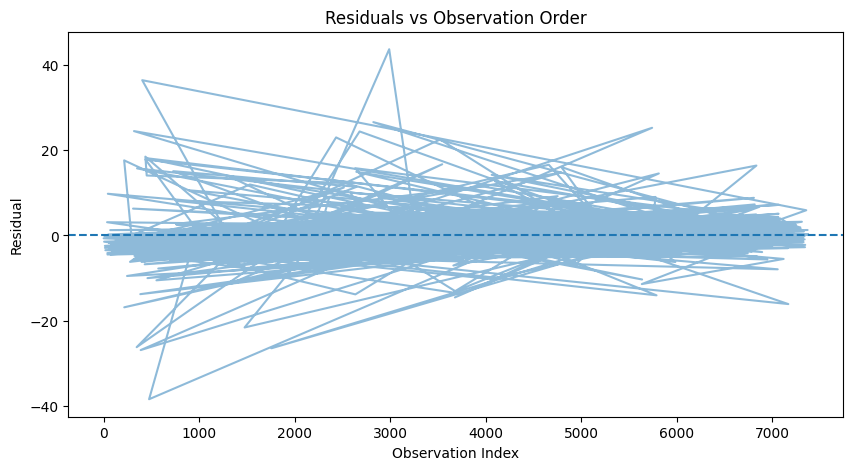

In [89]:
plt.figure(figsize=(10, 5))

plt.plot(residuals, alpha = 0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Observation Index')
plt.ylabel('Residual')
plt.title('Residuals vs Observation Order')

plt.show()

In [90]:
import pandas as pd

res = pd.Series(residuals)

print(res.autocorr(lag=1))

0.018218213076650676


#### The value is close 0, so ths assumption is fairly true. The intuition for this metric will be clear after timerseries.

#### 5. Check for multicollinearity

In [91]:
X_train_tansformed = preprocessor.fit_transform(X_train)
X_train_tansformed

array([[-0.85948474, -0.88701194, -0.4469565 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.2702634 , -0.88701194, -0.0188267 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.31895794,  0.21450494, -0.27570458, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.6135686 ,  1.31602182,  1.0943108 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.12295807,  0.21450494,  0.06679926, ...,  0.        ,
         1.        ,  0.        ],
       [ 2.23392728,  1.31602182,  1.06576881, ...,  0.        ,
         0.        ,  1.        ]], shape=(5908, 90))

In [92]:
preprocessor.get_feature_names_out()

array(['scaled__Engine Size(L)', 'scaled__Cylinders',
       'scaled__Fuel Consumption City (L/100 km)',
       'scaled__Fuel Consumption Hwy (L/100 km)',
       'encoded__Make_ALFA ROMEO', 'encoded__Make_ASTON MARTIN',
       'encoded__Make_AUDI', 'encoded__Make_BENTLEY', 'encoded__Make_BMW',
       'encoded__Make_BUGATTI', 'encoded__Make_BUICK',
       'encoded__Make_CADILLAC', 'encoded__Make_CHEVROLET',
       'encoded__Make_CHRYSLER', 'encoded__Make_DODGE',
       'encoded__Make_FIAT', 'encoded__Make_FORD',
       'encoded__Make_GENESIS', 'encoded__Make_GMC',
       'encoded__Make_HONDA', 'encoded__Make_HYUNDAI',
       'encoded__Make_INFINITI', 'encoded__Make_JAGUAR',
       'encoded__Make_JEEP', 'encoded__Make_KIA',
       'encoded__Make_LAMBORGHINI', 'encoded__Make_LAND ROVER',
       'encoded__Make_LEXUS', 'encoded__Make_LINCOLN',
       'encoded__Make_MASERATI', 'encoded__Make_MAZDA',
       'encoded__Make_MERCEDES-BENZ', 'encoded__Make_MINI',
       'encoded__Make_MITSUBISHI'

In [93]:
vif = pd.DataFrame()

vif["Feature"] = preprocessor.get_feature_names_out()
vif["VIF"] = [
    variance_inflation_factor(X_train_tansformed, i)
    for i in range(X_train_tansformed.shape[1])
]

print(vif.sort_values("VIF", ascending=False))

                                     Feature        VIF
2   scaled__Fuel Consumption City (L/100 km)  31.965975
3    scaled__Fuel Consumption Hwy (L/100 km)  25.221055
88                      encoded__Fuel Type_X  23.972759
74                 encoded__Transmission_AS6  21.997802
89                      encoded__Fuel Type_Z  21.977033
..                                       ...        ...
72                 encoded__Transmission_AS4   1.094669
9                      encoded__Make_BUGATTI   1.094530
70                 encoded__Transmission_AM9   1.037967
40                         encoded__Make_SRT   1.028739
87                      encoded__Fuel Type_N   1.015284

[90 rows x 2 columns]


#### The VIF value is really high, lets remove the highest multicollinearity features and check

In [94]:
X = df.drop('CO2 Emissions(g/km)', axis=1)
y = df['CO2 Emissions(g/km)']

In [95]:
R2_DROP_THRESHOLD = 0.02  # Allow max 2% drop in R²

results = []

while len(X.columns) > 1:

    # Build preprocessor
    preprocessor = ColumnTransformer([
        ('scaled',
         StandardScaler(),
         X.select_dtypes(include=['number']).columns),

        ('encoded',
         OneHotEncoder(
             drop='first',
             sparse_output=False,
             handle_unknown='ignore'
         ),
         X.select_dtypes(include=['object']).columns)
    ])

    # Current model
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=59
    )

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)

    features_count = X_train_transformed.shape[1]

    vif_df = pd.DataFrame({
        'Feature': preprocessor.get_feature_names_out(),
        'VIF': [
            variance_inflation_factor(X_train_transformed, i)
            for i in range(features_count)
        ]
    })

    max_vif = vif_df['VIF'].max()

    model = LinearRegression()
    model.fit(X_train_transformed, y_train)

    y_pred = model.predict(X_test_transformed)

    current_r2 = r2_score(y_test, y_pred)

    n = len(y_test)
    adj_r2 = 1 - (1-current_r2)*(n-1)/(n-features_count-1)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Stop if VIF acceptable
    if max_vif < 10:
        results.append({
            'n_features': features_count,
            'max_vif': round(max_vif, 2),
            'removed_feature': None,
            'r2': round(current_r2, 4),
            'adj_r2': round(adj_r2, 4),
            'r2_after_drop': None,
            'rmse': round(rmse, 4),
            'mae': round(mae, 4)
        })
        break

    # Candidate feature
    feature_to_drop = (
        vif_df.sort_values('VIF', ascending=False)
              .iloc[0]['Feature']
    )

    original_feature = (
        feature_to_drop.split('__', 1)[1]
                       .split('_', 1)[0]
    )

    # Test model WITHOUT this feature
    X_candidate = X.drop(columns=[original_feature])

    preprocessor_candidate = ColumnTransformer([
        ('scaled',
         StandardScaler(),
         X_candidate.select_dtypes(include=['number']).columns),

        ('encoded',
         OneHotEncoder(
             drop='first',
             sparse_output=False,
             handle_unknown='ignore'
         ),
         X_candidate.select_dtypes(include=['object']).columns)
    ])

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_candidate, y,
        test_size=0.2,
        random_state=59
    )

    X_train_c = preprocessor_candidate.fit_transform(X_train_c)
    X_test_c = preprocessor_candidate.transform(X_test_c)

    model_c = LinearRegression()
    model_c.fit(X_train_c, y_train_c)

    candidate_r2 = r2_score(
        y_test_c,
        model_c.predict(X_test_c)
    )

    r2_drop = current_r2 - candidate_r2

    # Keep feature if performance drops too much
    if r2_drop > R2_DROP_THRESHOLD:
        print(
            f"Stopping: removing '{original_feature}' "
            f"would decrease R² by {r2_drop:.4f}"
        )
        break

    # Otherwise remove it
    results.append({
        'n_features': features_count,
        'max_vif': round(max_vif, 2),
        'removed_feature': original_feature,
        'r2': round(current_r2, 4),
        'adj_r2': round(adj_r2, 4),
        'r2_after_drop':round(candidate_r2, 4),
        'rmse': round(rmse, 4),
        'mae': round(mae, 4)
    })

    X = X_candidate

/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Stopping: removing 'Fuel Type' would decrease R² by 0.0609


/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [96]:
results_df = pd.DataFrame(results)
results_df

,n_features,max_vif,removed_feature,r2,adj_r2,r2_after_drop,rmse,mae
0,89,32.04,Fuel Consumption City (L/100 km),0.9943,0.9939,0.9752,4.3055,2.7725


In [97]:
print("Remaining Features:", list(X.columns))

Remaining Features: ['Make', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption Hwy (L/100 km)']


In [98]:
# Max VIF after remving high multicollinearity features

preprocessor = ColumnTransformer([
    ('scaled',
     StandardScaler(),
     X.select_dtypes(include=['number']).columns),

    ('encoded',
     OneHotEncoder(
         drop='first',
         sparse_output=False,
         handle_unknown='ignore'
     ),
     X.select_dtypes(include=['object']).columns)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=59
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

features_count = X_train_transformed.shape[1]

vif_df = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'VIF': [
        variance_inflation_factor(X_train_transformed, i)
        for i in range(features_count)
    ]
})

vif_df.sort_values('VIF', ascending=False)

/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Feature,VIF
86,encoded__Fuel Type_X,25.064822
87,encoded__Fuel Type_Z,22.743297
72,encoded__Transmission_AS6,21.723998
74,encoded__Transmission_AS8,20.013266
0,scaled__Engine Size(L),14.715878
...,...,...
70,encoded__Transmission_AS4,1.194332
51,encoded__Vehicle Class_STATION WAGON - MID-SIZE,1.140675
8,encoded__Make_BUGATTI,1.086165
39,encoded__Make_SRT,1.055957


#### Even though the VIF is still very high, we do not remove any other feature as it signifcantly drops the r-sqr value. R-sqr indicates the performance of the model. Presence of multicollinearity simply means that the features are dependepent on each other and the weight corresponding to feature and highly unstable and do not repsent correct interpretation of weights. The performace of the model is of utmost importance so we remove only "Fuel Consumption City (L/100 km)" feature.

#### Intuitively speaking removing "Fuel Consumption City (L/100 km)" does not hamper performance of the model a lot as it is highly correlated to "Fuel Consumption Highway (L/100 km)"

#### In totality, 'Make', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption Hwy (L/100 km)' features are of utmost importance and can represent the data as a linear model

### Polynomial Regression

#### Let's try training the Linear regression model on polynomial features. We'll create higher degree feature for numerical features only.

##### (The R-sqr value for linear regression model on the entire dataset was more than 0.99. The score for linear regression model on polynomial feature would be even more. Let's perform polynomial regression on shortlisted features from the above analysis only)

In [99]:
def reg_model(degree = 1):
    numeric_pipeline = Pipeline([
        ('poly', PolynomialFeatures(
            degree,
            include_bias=True
        )),
        ('scaler', StandardScaler())
    ])
    
    preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, numeric_cols),
        ('cat',
         OneHotEncoder(
             drop='first',
             handle_unknown='ignore'
         ),
         categorical_cols)
    ])
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    
    return model

In [100]:
X_new = df[list(X.columns)]
y_new = df['CO2 Emissions(g/km)']
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=17)

numeric_cols = X.select_dtypes(include=['number']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

for degree in [1,2,3,4,5]: 
    model = reg_model(degree)
    
    model.fit(X_train, y_train)
    
    r2_train = model.score(X_train, y_train)
    r2_test = model.score(X_test, y_test)
    print("Degree :", degree, "R-sqr(train) :", r2_train, "R-sqr(test) :", r2_test)

Degree : 1 R-sqr(train) : 0.9756025608309177 R-sqr(test) : 0.9754498571520104
Degree : 2 R-sqr(train) : 0.9808226803491042 R-sqr(test) : 0.9796586744017202
Degree : 3 R-sqr(train) : 0.981106270026338 R-sqr(test) : 0.979667301863023
Degree : 4 R-sqr(train) : 0.9818559587924461 R-sqr(test) : 0.9805171299328487
Degree : 5 R-sqr(train) : 0.9823063752847224 R-sqr(test) : 0.9804329234886435


The training linear regression model on polynomial features improves the performance slightly. By Occum's Razor principle we'll choose the linear regression model with degree 1 features only as it is much simpler and has almost the same score as model on higher degree features.

### Deriving Feature Importance
#### We can't look at the weights of the features to dertermine the feature importance in determining the output. We've got categorical features in the dataset also that are spread across multiple columns after encoding. 
#### Let's try permutation importance. Instead of looking at weights, we measure how much model performance drops when a feature is shuffled.

In [101]:
model = reg_model()
model.fit(X_train, y_train)

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=20,
    random_state=47
)

In [102]:
result

{'importances_mean': array([0.01533057, 0.01309833, 0.04616695, 0.01064303, 0.01757268,
        0.24558863, 1.54072699]),
 'importances_std': array([0.00084388, 0.0008113 , 0.00141455, 0.00043502, 0.00100872,
        0.0036458 , 0.03283156]),
 'importances': array([[0.01467445, 0.01664198, 0.01434888, 0.01510315, 0.01541493,
         0.01511532, 0.01416922, 0.0151103 , 0.0142692 , 0.01534089,
         0.01575071, 0.01578999, 0.01726704, 0.01590468, 0.01616042,
         0.01648366, 0.01496818, 0.01471016, 0.01410765, 0.01528069],
        [0.01234719, 0.01219428, 0.01411566, 0.01251557, 0.01321445,
         0.01408095, 0.0134243 , 0.01325321, 0.01244344, 0.01204211,
         0.01257358, 0.0131668 , 0.01208092, 0.01422518, 0.01414293,
         0.01421025, 0.01257189, 0.01240138, 0.01442612, 0.01253632],
        [0.04734636, 0.04808877, 0.04670474, 0.04540901, 0.04584693,
         0.04710954, 0.0445729 , 0.04631598, 0.04704629, 0.04519277,
         0.04411129, 0.04580317, 0.04857254, 0.047

In [103]:
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
})

importance_df.sort_values(
    'Importance',
    ascending=False
)

,Feature,Importance
6,Fuel Consumption Hwy (L/100 km),1.540727
5,Fuel Type,0.245589
2,Engine Size(L),0.046167
4,Transmission,0.017573
0,Make,0.015331
1,Vehicle Class,0.013098
3,Cylinders,0.010643


#### We can cleary see the order of feature importance in determining the value of CO2 emissions. 

#### Following is the order of feature importance: Fuel Consumption Hwy (L/100 km)	> Fuel Type > Engine Size(L) > Transmission > Make > Vehicle Class > Cylinders	

### Conclusion

##### 1. The objective of this case study is to analyze this dataset to uncover hidden patterns, identify the major contributors to CO₂ emissions, and develop predictive models to support policy and design decisions in the automotive sector.
##### We have successfully trained a linear regression model with R-sqr value 0.975, to model a linear relationship between some of the features and CO2 emissions. 
##### 2. We have considered on the following features in descending order of feature importance to design the model: Fuel Consumption Hwy (L/100 km) > Fuel Type > Engine Size(L) > Transmission > Make > Vehicle Class > Cylinders
##### 3. "Fuel Consumption Comb (L/100 km)" and "Fuel Consumption Comb (mpg)" features were dropped earlier in the case study because there values were highly correlated and easily determined by "Fuel Consumption Hwy (L/100 km)" and "Fuel Consumption City (L/100 km)" features. We have done a detailed analysis for the same.
##### 4. "Fuel Consumption City (L/100 km)" was also removed later as it was adding a lot of multicollinearity the model. Removing it reduced the performance of the model slightly, but did not the model a lot.
##### 5. "Model" feature was also dropped during EDA, because it had way too many unique values and the frequency for each unique value was way too low. Encoding it would have lead to addition of thousands of new features making the model highly prone to overfitting.
##### 6. We also tried to train model on polynomial features, which increase the model performance slightly, but we stuck with model with linear features due to Occum's razor principle.
##### 7. From the feature importance we can observe that "Fuel Consumption Hwy (L/100 km)" feature holds utmost importance in determining C02 emission. It is significantly more than any other feature. So from a business case point of view, we need to focus on reducing the Fuel consmption of the vehicle the most.
##### Note: Since "Fuel Consumption Hwy (L/100 km)", "Fuel Consumption City (L/100 km)", "Fuel Consumption Comb (L/100 km)" and "Fuel Consumption Comb (mpg)" are highly correlated, it is possible that we could have selected some other feature instead of "Fuel Consumption Hwy (L/100 km)" and still trained an as good model as we've trained right now, but the business case insight and feature importances would still be almost same.